## D1.2 – Project Submission

In [1]:
import kagglehub
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\js834\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Display some information before preprocessing

In [2]:
path = kagglehub.dataset_download("muratkokludataset/dry-bean-dataset")
archivos = glob.glob(os.path.join(path, "**", "*.xlsx"), recursive=True)

archivo_datos = archivos[0]
df = pd.read_excel(archivo_datos)

display(df.head()) 

df.info() 

duplicate_count = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_count}")

print(f"Number of null rows: {df.isnull().sum()}")

df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


### 1. Data Processing

Remove duplicates

In [3]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Shape with duplicates:", df.shape)
print("Shape without duplicates:", df_clean.shape)

Shape with duplicates: (13611, 17)
Shape without duplicates: (13543, 17)


Document null analysis

In [4]:
df_clean.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Label Encoding on the target

In [5]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(df_clean['Class'])

Stratified Train/Test Split

In [6]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["Class"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

y_train = pd.Series(y_train, name="Class")
y_test  = pd.Series(y_test, name="Class")

StandardScaler (fit only on train)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### 2. Imbalance Analysis and Mitigation 


In [8]:
train_counts = pd.Series(y_train).value_counts()
train_percent = pd.Series(y_train).value_counts(normalize=True) * 100

imbalance_summary = pd.DataFrame({
    'count': train_counts,
    'percentage (%)': train_percent.round(2)
})
imbalance_summary.index = le.classes_[imbalance_summary.index]

display(imbalance_summary)

imbalance_ratio = train_counts.max() / train_counts.min()
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")


,count,percentage (%)
DERMASON,2837,26.19
SIRA,2109,19.47
SEKER,1621,14.96
HOROZ,1488,13.73
CALI,1304,12.04
BARBUNYA,1057,9.76
BOMBAY,418,3.86


Imbalance ratio (majority/minority): 6.79


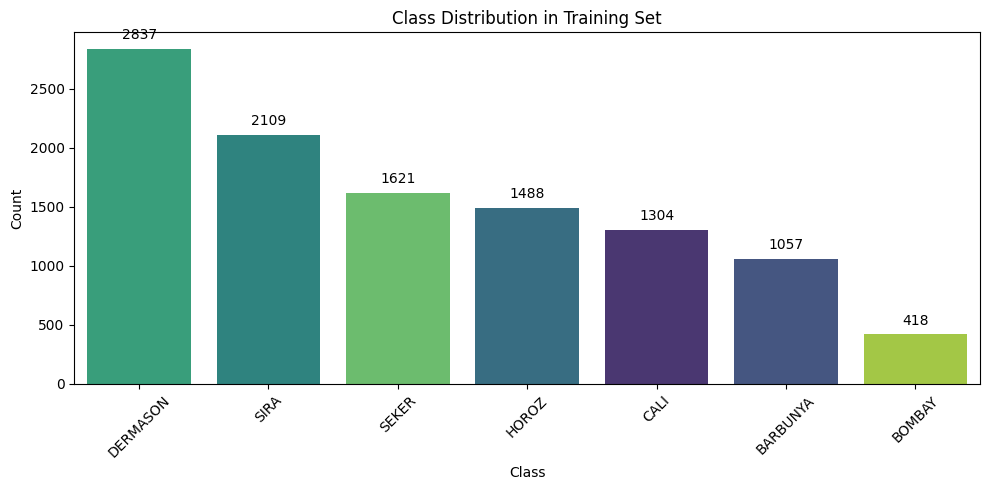

In [9]:
plt.figure(figsize=(10, 5))
y_train_labels = pd.Series(y_train).map(dict(enumerate(le.classes_)))

ax = sns.countplot(
    x=y_train_labels,
    order=y_train_labels.value_counts().index,
    hue=y_train_labels,
    palette='viridis',
    legend=False
)

plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=10,
        xytext=(0, 5), textcoords='offset points'
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [10]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek

RandomOverSampler

In [11]:
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train_scaled, y_train)

RandomUnderSampler


In [12]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train_scaled, y_train)

SMOTE

In [13]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

SMOTEENN

Combines SMOTE + Edited Nearest Neighbours (ENN)

In [14]:
smoteenn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(X_train_scaled, y_train)

SMOTETomek

Combines SMOTE + Tomek Links

In [15]:
smotetomek = SMOTETomek(random_state=42)
X_train_smotetomek, y_train_smotetomek = smotetomek.fit_resample(X_train_scaled, y_train)

And represent the number of instances for each one

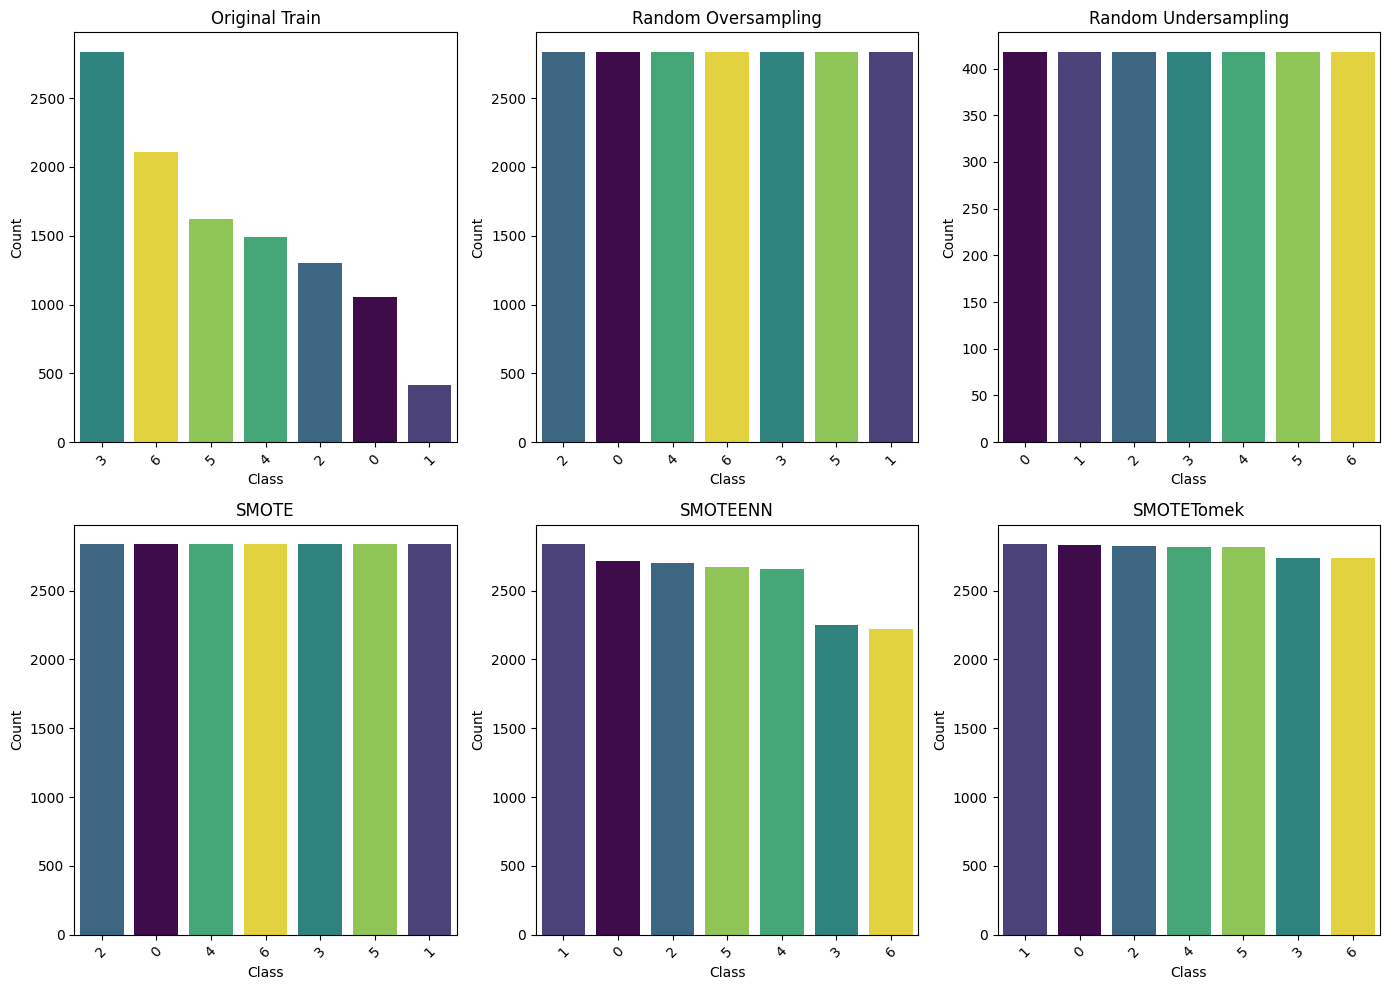

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

datasets = {
    "Original Train": y_train,
    "Random Oversampling": y_train_over,
    "Random Undersampling": y_train_under,
    "SMOTE": y_train_smote,
    "SMOTEENN":            y_train_smoteenn,
    "SMOTETomek":          y_train_smotetomek,
}

for ax, (title, y_data) in zip(axes.flatten(), datasets.items()):
    order = y_data.value_counts().index
    sns.countplot(
        x=y_data,
        order=order,
        hue=y_data,
        palette="viridis",
        legend=False,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [17]:
summary_resampling = pd.DataFrame({
    "Original": y_train.value_counts(),
    "Oversampling": y_train_over.value_counts(),
    "Undersampling": y_train_under.value_counts(),
    "SMOTE": y_train_smote.value_counts(),
    "SMOTEENN":     pd.Series(y_train_smoteenn).value_counts(),
    "SMOTETomek":   pd.Series(y_train_smotetomek).value_counts(),
}).fillna(0).astype(int)

display(summary_resampling)

,Original,Oversampling,Undersampling,SMOTE,SMOTEENN,SMOTETomek
Class,,,,,,
0,1057,2837,418,2837,2714,2831
1,418,2837,418,2837,2837,2837
2,1304,2837,418,2837,2702,2828
3,2837,2837,418,2837,2249,2741
4,1488,2837,418,2837,2655,2819
5,1621,2837,418,2837,2674,2818
6,2109,2837,418,2837,2222,2737


3. Model Comparison and Hyperparameter Tuning 